In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)

# Correct file path (relative to notebooks folder)
file_path = '../data/datainsurance_data.txt'

# Load with default C engine (fast)
df = pd.read_csv(file_path, sep='|', low_memory=False, on_bad_lines='skip')

# Clean column names
df.columns = df.columns.str.strip()

# Convert date
df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'], errors='coerce')

print("✅ Data loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()[:10]}...")  # first 10 columns
df.head()

✅ Data loaded successfully!
Shape: (1000098, 52)
Columns: ['UnderwrittenCoverID', 'PolicyID', 'TransactionMonth', 'IsVATRegistered', 'Citizenship', 'LegalType', 'Title', 'Language', 'Bank', 'AccountType']...


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
1,145249,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.929825,0.0
2,145249,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,0.01,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0
3,145255,12827,2015-05-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,512.848070,0.0
4,145255,12827,2015-07-01,True,,Close Corporation,Mr,English,First National Bank,Current account,Not specified,Not specified,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0,2597.0,130.0,S/D,4.0,6/2002,119300.0,Yes,No,119300,More than 6 months,NaN,NaN,NaN,NaN,NaN,119300.00,Monthly,584.6468,Mobility - Metered Taxis - R2000,Own damage,Own Damage,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.000000,0.0


In [9]:
# Info and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000098 entries, 0 to 1000097
Data columns (total 52 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   UnderwrittenCoverID       1000098 non-null  int64         
 1   PolicyID                  1000098 non-null  int64         
 2   TransactionMonth          1000098 non-null  datetime64[us]
 3   IsVATRegistered           1000098 non-null  bool          
 4   Citizenship               1000098 non-null  str           
 5   LegalType                 1000098 non-null  str           
 6   Title                     1000098 non-null  str           
 7   Language                  1000098 non-null  str           
 8   Bank                      854137 non-null   str           
 9   AccountType               959866 non-null   str           
 10  MaritalStatus             991839 non-null   str           
 11  Gender                    990562 non-null   str           
 1

In [10]:
# Missing values summary
missing = df.isnull().sum()
missing_pct = 100 * missing / len(df)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False).head(10)

,Missing,Percentage
NumberOfVehiclesInFleet,1000098,100.000000
CrossBorder,999400,99.930207
CustomValueEstimate,779642,77.956560
WrittenOff,641901,64.183810
Converted,641901,64.183810
Rebuilt,641901,64.183810
NewVehicle,153295,15.327998
Bank,145961,14.594670
AccountType,40232,4.022806
Gender,9536,0.953507


In [11]:
# Descriptive stats for numeric columns
df.describe()

,UnderwrittenCoverID,PolicyID,TransactionMonth,PostalCode,mmcode,RegistrationYear,Cylinders,cubiccapacity,kilowatts,NumberOfDoors,CustomValueEstimate,NumberOfVehiclesInFleet,SumInsured,CalculatedPremiumPerTerm,TotalPremium,TotalClaims
count,1.000098e+06,1.000098e+06,1000098,1.000098e+06,9.995460e+05,1.000098e+06,999546.000000,999546.000000,999546.000000,999546.000000,2.204560e+05,0.0,1.000098e+06,1.000098e+06,1.000098e+06,1.000098e+06
mean,1.048175e+05,7.956682e+03,2015-02-28 10:49:29.147424,3.020601e+03,5.487770e+07,2.010225e+03,4.046642,2466.743258,97.207919,4.019250,2.255311e+05,NaN,6.041727e+05,1.178757e+02,6.190550e+01,6.486119e+01
min,1.000000e+00,1.400000e+01,2013-10-01 00:00:00,1.000000e+00,4.041200e+06,1.987000e+03,0.000000,0.000000,0.000000,0.000000,2.000000e+04,NaN,1.000000e-02,0.000000e+00,-7.825768e+02,-1.200241e+04
25%,5.514300e+04,4.500000e+03,2015-01-01 00:00:00,8.270000e+02,6.005692e+07,2.008000e+03,4.000000,2237.000000,75.000000,4.000000,1.350000e+05,NaN,5.000000e+03,3.224800e+00,0.000000e+00,0.000000e+00
50%,9.408300e+04,7.071000e+03,2015-04-01 00:00:00,2.000000e+03,6.005842e+07,2.011000e+03,4.000000,2694.000000,111.000000,4.000000,2.200000e+05,NaN,7.500000e+03,8.436900e+00,2.178333e+00,0.000000e+00
75%,1.391900e+05,1.107700e+04,2015-06-01 00:00:00,4.180000e+03,6.005842e+07,2.013000e+03,4.000000,2694.000000,111.000000,4.000000,2.800000e+05,NaN,2.500000e+05,9.000000e+01,2.192982e+01,0.000000e+00
max,3.011750e+05,2.324600e+04,2015-08-01 00:00:00,9.870000e+03,6.506535e+07,2.015000e+03,10.000000,12880.000000,309.000000,6.000000,2.655000e+07,NaN,1.263620e+07,7.442217e+04,6.528260e+04,3.930921e+05
std,6.329371e+04,5.290039e+03,NaN,2.649854e+03,1.360381e+07,3.261391e+00,0.294020,442.800640,19.393256,0.468314,5.645157e+05,NaN,1.508332e+06,3.997017e+02,2.302845e+02,2.384075e+03


In [12]:
# Ensure numeric
df['TotalPremium'] = pd.to_numeric(df['TotalPremium'], errors='coerce')
df['TotalClaims'] = pd.to_numeric(df['TotalClaims'], errors='coerce')

# Drop rows with missing critical values
df_clean = df.dropna(subset=['TotalPremium', 'TotalClaims']).copy()

# Loss Ratio (avoid division by zero)
df_clean['LossRatio'] = df_clean.apply(
    lambda row: row['TotalClaims'] / row['TotalPremium'] if row['TotalPremium'] != 0 else 0,
    axis=1
)

# Margin
df_clean['Margin'] = df_clean['TotalPremium'] - df_clean['TotalClaims']

print("Overall Loss Ratio:", df_clean['LossRatio'].mean())
print("Total Margin (sum):", df_clean['Margin'].sum())

Overall Loss Ratio: 0.21636986096323912
Total Margin (sum): -2955983.474269499


In [13]:
print("Loss Ratio by Province:")
print(df_clean.groupby('Province')['LossRatio'].mean().sort_values())

print("\nLoss Ratio by VehicleType:")
print(df_clean.groupby('VehicleType')['LossRatio'].mean().sort_values())

print("\nLoss Ratio by Gender:")
print(df_clean.groupby('Gender')['LossRatio'].mean())

Loss Ratio by Province:
Province
Free State       0.077792
Northern Cape    0.116388
Eastern Cape     0.152974
KwaZulu-Natal    0.174868
North West       0.178830
Western Cape     0.193640
Mpumalanga       0.235858
Limpopo          0.252857
Gauteng          0.262216
Name: LossRatio, dtype: float64

Loss Ratio by VehicleType:
VehicleType
Bus                  0.000000
Passenger Vehicle    0.208682
Medium Commercial    0.305509
Light Commercial     0.364845
Heavy Commercial     0.457233
Name: LossRatio, dtype: float64

Loss Ratio by Gender:
Gender
Female           0.247919
Male             0.157443
Not specified    0.218548
Name: LossRatio, dtype: float64


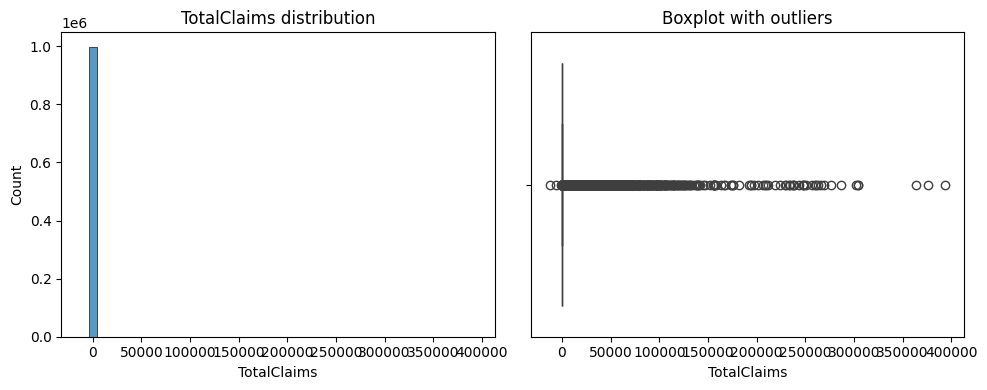

99th percentile of TotalClaims: 0.0
Rows with claims > 0.0: 2788


In [14]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df_clean['TotalClaims'], bins=50)
plt.title('TotalClaims distribution')

plt.subplot(1,2,2)
sns.boxplot(x=df_clean['TotalClaims'])
plt.title('Boxplot with outliers')
plt.tight_layout()
plt.show()

# 99th percentile
q99 = df_clean['TotalClaims'].quantile(0.99)
print(f"99th percentile of TotalClaims: {q99}")
print(f"Rows with claims > {q99}: {(df_clean['TotalClaims'] > q99).sum()}")

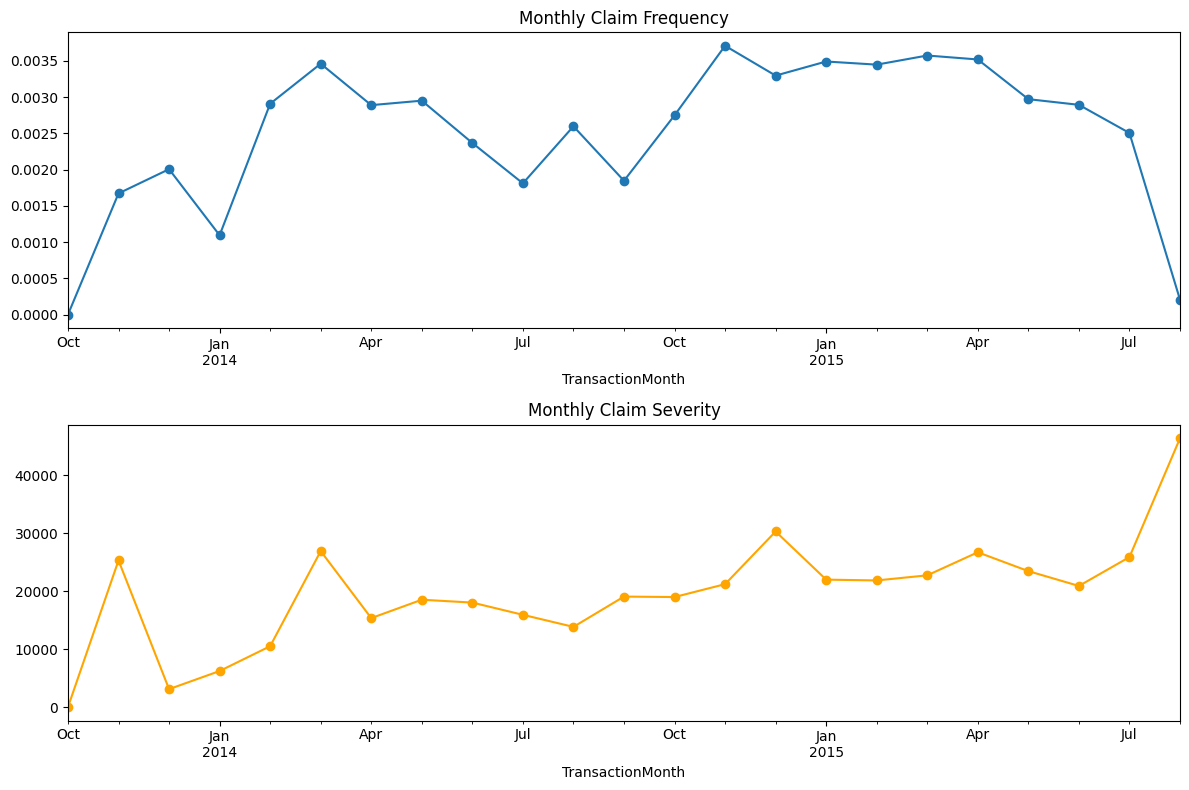

In [16]:
monthly = df_clean.groupby(pd.Grouper(key='TransactionMonth', freq='ME')).agg(
    claim_freq=('TotalClaims', lambda x: (x > 0).mean()),
    claim_severity=('TotalClaims', lambda x: x[x>0].mean() if (x>0).sum() > 0 else 0)
)

fig, axes = plt.subplots(2,1, figsize=(12,8))
monthly['claim_freq'].plot(ax=axes[0], marker='o')
axes[0].set_title('Monthly Claim Frequency')
monthly['claim_severity'].plot(ax=axes[1], marker='o', color='orange')
axes[1].set_title('Monthly Claim Severity')
plt.tight_layout()
plt.show()

In [17]:
claims_only = df_clean[df_clean['TotalClaims'] > 0]
if 'make' in claims_only.columns:
    claim_by_make = claims_only.groupby('make')['TotalClaims'].mean().sort_values()
    print("Lowest 5:")
    print(claim_by_make.head(5))
    print("\nHighest 5:")
    print(claim_by_make.tail(5))
else:
    print("Column 'make' not found. Check available columns.")

Lowest 5:
make
FORD                                   2040.473684
MITSUBISHI                             2378.596491
MARCOPOLO                              7996.535088
CHEVROLET                              8222.473684
TOYOTA                                 8969.587719
Name: TotalClaims, dtype: float64

Highest 5:
make
MERCEDES-BENZ                           34079.340852
GOLDEN JOURNEY                          46169.723522
B.A.W                                   47856.245614
HYUNDAI                                 56663.492325
POLARSUN                               125197.843333
Name: TotalClaims, dtype: float64


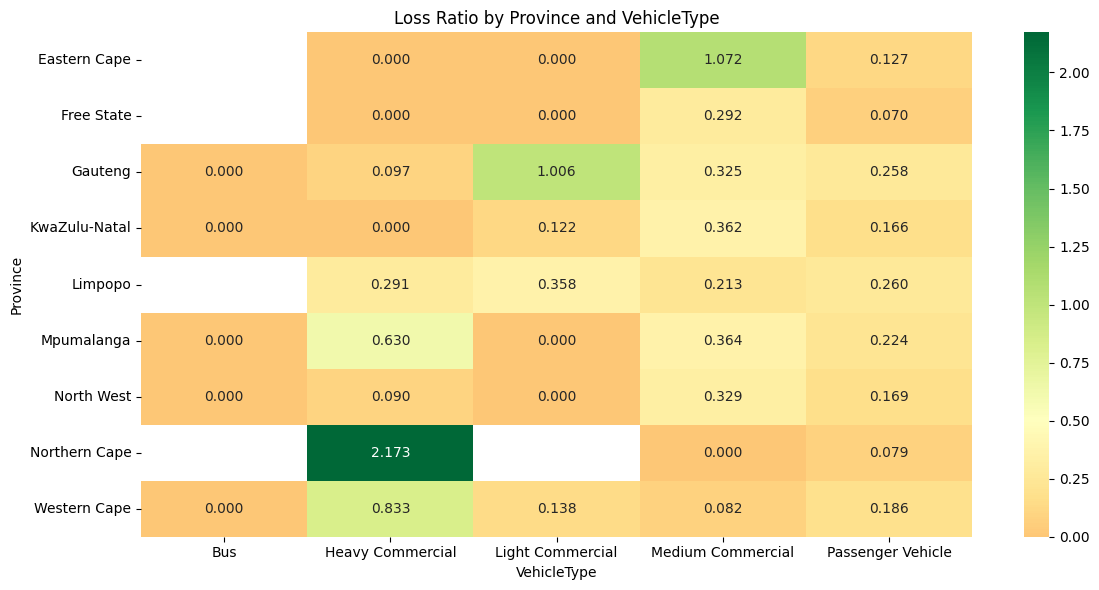

In [18]:
pivot = df_clean.pivot_table(values='LossRatio', index='Province', columns='VehicleType', aggfunc='mean')
plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap='RdYlGn', center=0.5, fmt='.3f')
plt.title('Loss Ratio by Province and VehicleType')
plt.tight_layout()
plt.show()

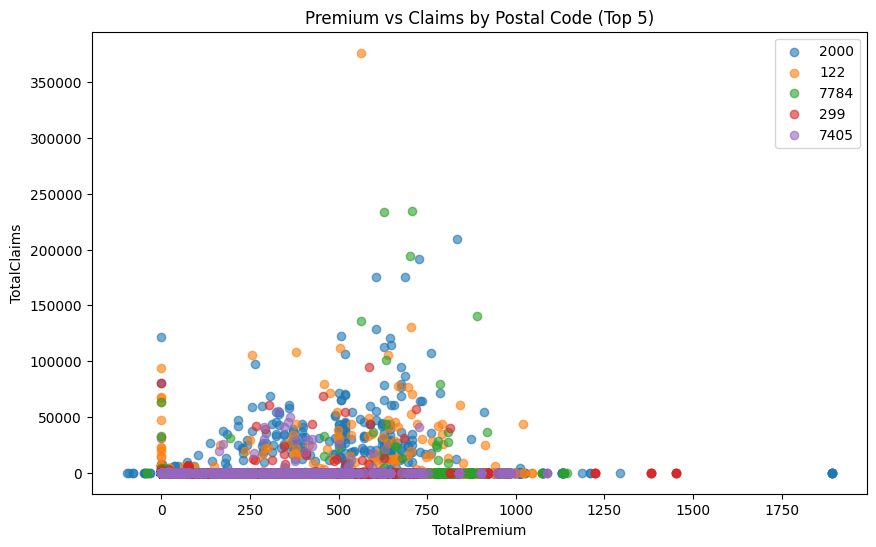

In [19]:
top_codes = df_clean['PostalCode'].value_counts().head(5).index
plt.figure(figsize=(10,6))
for code in top_codes:
    subset = df_clean[df_clean['PostalCode'] == code]
    plt.scatter(subset['TotalPremium'], subset['TotalClaims'], label=code, alpha=0.6)
plt.xlabel('TotalPremium')
plt.ylabel('TotalClaims')
plt.title('Premium vs Claims by Postal Code (Top 5)')
plt.legend()
plt.show()

In [21]:
# Columns that might have comma decimals
cols_to_clean = ['CustomValueEstimate', 'CapitalOutstanding']

for col in cols_to_clean:
    if col in df_clean.columns:
        # Replace comma with dot and convert to float
        df_clean[col] = df_clean[col].astype(str).str.replace(',', '.', regex=False)
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')
        print(f"Converted {col} to numeric")
plt.show()

Converted CustomValueEstimate to numeric
Converted CapitalOutstanding to numeric


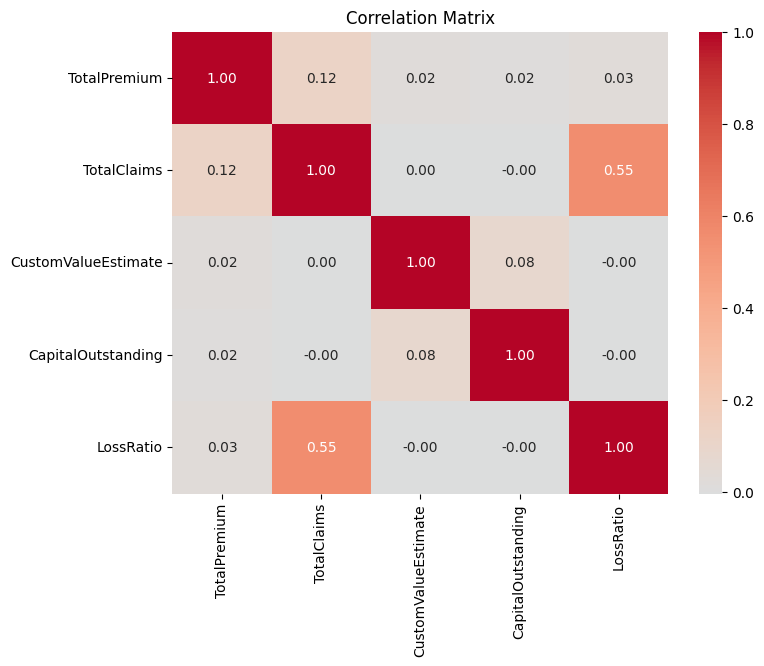

In [23]:
numeric_cols = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'CapitalOutstanding', 'LossRatio']
corr = df_clean[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.show()